# Final Transfer-Aware Model Comparison

Reads `artifacts/final_transfer/model_comparison.csv` (updated by
`scripts/fix_model_comparison_scores.py`) and DANN v2 results.
**Does not retrain any model.**

> **Note on DANN v2 models:**  DANN v2 models are **not** selected as
> firewall candidates unless their LODO metrics are available and
> competitive.  The current DANN v2 run shows no meaningful reduction in
> embedding domain fingerprinting — see Section 12 for details.

Sections:

1. Setup
2. Research ranking — all models (may lack LODO)
3. Transfer ranking — models with full LODO evaluation
4. Firewall deployment ranking — runtime-compatible + LODO-evaluated
5. Pooled ROC-AUC comparison
6. LODO AUC heatmap
7. LODO minimum AUC ranking
8. Domain fingerprint AUC comparison
9. VPN AUC vs Domain AUC scatter
10. Calibration curves
11. Confusion-matrix grid (recommended slots)
12. Threshold stability
13. Anti-fingerprint feature importance
14. Final recommendation summary
15. DANN v2 — architecture verification & domain reduction


## 1. Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except Exception:
    pass

plt.rcParams['figure.dpi'] = 110

ROOT = Path('..').resolve()
ART  = ROOT / 'artifacts' / 'final_transfer'
REC  = ART  / 'recommended'

print('Artifact root :', ART, '->', 'EXISTS' if ART.exists() else 'MISSING')
print('Recommend dir :', REC, '->', 'EXISTS' if REC.exists() else 'MISSING')

comp = pd.read_csv(ART / 'model_comparison.csv')
print(f'{len(comp)} model rows loaded.')

# Ensure new scoring columns exist (backwards compat)
if 'deployment_eligible' not in comp.columns:
    comp['deployment_eligible'] = (
        comp.get('runtime_compatible', False).astype(bool)
        & comp['lodo_min_auc'].notna()
        & comp['lodo_mean_auc'].notna()
    )
if 'deployment_final_score' not in comp.columns:
    comp['deployment_final_score'] = comp.apply(
        lambda r: r['final_score']
            if pd.notna(r.get('lodo_min_auc')) and pd.notna(r.get('lodo_mean_auc'))
            else float('nan'),
        axis=1)

print(f"deployment_eligible : {comp['deployment_eligible'].sum()} models")
print(f"transfer_evaluated  : {comp['lodo_min_auc'].notna().sum()} models")


Artifact root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer -> EXISTS
Recommend dir : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer\recommended -> EXISTS
46 model rows loaded.
deployment_eligible : 28 models
transfer_evaluated  : 28 models


## 2. Research ranking (all models)
All models sorted by legacy `final_score`.
Rows where `lodo_min_auc` is NaN used `pooled_auc` as a substitute — those
are **not transfer-evaluated** and should not be selected for deployment.


In [2]:
research_cols = ['model_id', 'family', 'feature_family',
    'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
    'domain_auc', 'embedding_domain_auc',
    'fpr', 'ece', 'deployment_eligible', 'final_score']
research_cols = [c for c in research_cols if c in comp.columns]

research = comp.sort_values('final_score', ascending=False).reset_index(drop=True)
research['transfer_evaluated'] = research['lodo_min_auc'].notna()
print('=== Research ranking (top 20) ===')
research[research_cols + ['transfer_evaluated']].head(20).round(4)


=== Research ranking (top 20) ===


,model_id,family,feature_family,pooled_auc,lodo_min_auc,lodo_mean_auc,domain_auc,embedding_domain_auc,fpr,ece,deployment_eligible,final_score,transfer_evaluated
0,dann_v2__lam1.0_enc64x32_do0.2_bn1_balnone,dann_v2,full_canonical,0.9787,NaN,NaN,1.0,0.9999,0.0190,0.0114,False,0.9427,False
1,dann_v2__lam0.5_enc32x16_do0.2_bn1_balboth,dann_v2,full_canonical,0.9711,NaN,NaN,1.0,0.9999,0.0106,0.0857,False,0.9338,False
2,dann_v2__lam0.1_enc128x64_do0.2_bn1_balboth,dann_v2,full_canonical,0.9785,NaN,NaN,1.0,1.0000,0.0203,0.0705,False,0.9243,False
3,dann_v2__lam1.0_enc32x16_do0.2_bn1_balboth,dann_v2,full_canonical,0.9656,NaN,NaN,1.0,0.9999,0.0108,0.0964,False,0.9225,False
4,dann_v2__lam0.1_enc32x16_do0.2_bn1_balboth,dann_v2,full_canonical,0.9646,NaN,NaN,1.0,0.9999,0.0118,0.0801,False,0.9225,False
5,dann_v2__lam0.5_enc64x32_do0.2_bn1_balboth,dann_v2,full_canonical,0.9618,NaN,NaN,1.0,1.0000,0.0133,0.0555,False,0.9204,False
6,dann_v2__lam2.0_enc64x32_do0.2_bn1_balboth,dann_v2,full_canonical,0.9659,NaN,NaN,1.0,1.0000,0.0098,0.1155,False,0.9200,False
7,dann_v2__lam1.0_enc64x32_do0.2_bn1_baldomain,dann_v2,full_canonical,0.9526,NaN,NaN,1.0,0.9999,0.0128,0.0252,False,0.9157,False
8,dann_v2__lam5.0_enc128x64_do0.2_bn1_balboth,dann_v2,full_canonical,0.9586,NaN,NaN,1.0,0.9998,0.0111,0.0813,False,0.9148,False
9,dann_v2__lam0.5_enc128x64_do0.2_bn1_balboth,dann_v2,full_canonical,0.9663,NaN,NaN,1.0,0.9999,0.0181,0.0708,False,0.9114,False


## 3. Transfer ranking (LODO-evaluated models only)
Only models where `lodo_min_auc` AND `lodo_mean_auc` are not NaN.
Sorted by `lodo_min_auc` (worst-case transfer floor).


In [3]:
transfer = (comp[comp['lodo_min_auc'].notna() & comp['lodo_mean_auc'].notna()]
            .sort_values('lodo_min_auc', ascending=False)
            .reset_index(drop=True))
transfer_cols = ['model_id', 'family', 'feature_family',
    'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
    'lodo_iscx_auc', 'lodo_usbvpn_auc', 'lodo_vnat_auc',
    'domain_auc', 'deployment_eligible', 'deployment_final_score']
transfer_cols = [c for c in transfer_cols if c in transfer.columns]
print(f'{len(transfer)} transfer-evaluated models')
transfer[transfer_cols].round(4)


28 transfer-evaluated models


,model_id,family,feature_family,pooled_auc,lodo_min_auc,lodo_mean_auc,lodo_iscx_auc,lodo_usbvpn_auc,lodo_vnat_auc,domain_auc,deployment_eligible,deployment_final_score
0,full_canonical__lgbm,lgbm,full_canonical,0.9994,0.6164,0.6531,0.6164,NaN,0.6898,1.0000,True,0.6836
1,full_canonical__xgb,xgb,full_canonical,0.9990,0.6164,0.6531,0.6164,NaN,0.6898,1.0000,True,0.6831
2,full_canonical__cat,cat,full_canonical,0.9980,0.6164,0.6531,0.6164,NaN,0.6898,1.0000,True,0.6829
3,full_canonical__calibrated_ensemble,calibrated_ensemble,full_canonical,0.9800,0.6164,0.6531,0.6164,NaN,0.6898,1.0000,True,0.6820
4,full_canonical__bagging,bagging,full_canonical,0.9989,0.6164,0.6531,0.6164,NaN,0.6898,1.0000,True,0.6795
5,timing_shape__xgb,xgb,timing_shape,0.9377,0.4512,0.4756,0.4512,NaN,0.5000,0.9891,True,0.4341
6,timing_shape__lgbm,lgbm,timing_shape,0.9423,0.4512,0.4756,0.4512,NaN,0.5000,0.9891,True,0.4336
7,timing_shape__cat,cat,timing_shape,0.9318,0.4512,0.4756,0.4512,NaN,0.5000,0.9891,True,0.4333
8,timing_shape__calibrated_ensemble,calibrated_ensemble,timing_shape,0.8881,0.4512,0.4756,0.4512,NaN,0.5000,0.9891,True,0.4300
9,timing_shape__bagging,bagging,timing_shape,0.9440,0.4512,0.4756,0.4512,NaN,0.5000,0.9891,True,0.4191


## 4. Firewall deployment ranking
Models that are **deployment-eligible**:
- `runtime_compatible == True`
- `lodo_min_auc` and `lodo_mean_auc` are not NaN
- `fpr` and `ece` are not NaN

Sorted by `deployment_final_score` (penalises missing LODO; formula identical
to `final_score` but returns NaN when LODO is absent).


In [4]:
deploy = (comp[comp['deployment_eligible'] == True]
          .sort_values('deployment_final_score', ascending=False)
          .reset_index(drop=True))
deploy_cols = ['model_id', 'family', 'feature_family',
    'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
    'domain_auc', 'fpr', 'ece',
    'threshold_instability', 'runtime_compatible',
    'deployment_final_score']
deploy_cols = [c for c in deploy_cols if c in deploy.columns]
print(f'{len(deploy)} deployment-eligible models')
deploy[deploy_cols].round(4)


28 deployment-eligible models


,model_id,family,feature_family,pooled_auc,lodo_min_auc,lodo_mean_auc,domain_auc,fpr,ece,threshold_instability,runtime_compatible,deployment_final_score
0,full_canonical__lgbm,lgbm,full_canonical,0.9994,0.6164,0.6531,1.0000,0.0025,0.0026,0.0346,True,0.6836
1,full_canonical__xgb,xgb,full_canonical,0.9990,0.6164,0.6531,1.0000,0.0018,0.0046,0.0346,True,0.6831
2,full_canonical__cat,cat,full_canonical,0.9980,0.6164,0.6531,1.0000,0.0023,0.0055,0.0346,True,0.6829
3,full_canonical__calibrated_ensemble,calibrated_ensemble,full_canonical,0.9800,0.6164,0.6531,1.0000,0.0039,0.0089,0.0346,True,0.6820
4,full_canonical__bagging,bagging,full_canonical,0.9989,0.6164,0.6531,1.0000,0.0031,0.0189,0.0346,True,0.6795
5,timing_shape__xgb,xgb,timing_shape,0.9377,0.4512,0.4756,0.9891,0.0031,0.0080,0.0117,True,0.4341
6,timing_shape__lgbm,lgbm,timing_shape,0.9423,0.4512,0.4756,0.9891,0.0040,0.0098,0.0117,True,0.4336
7,timing_shape__cat,cat,timing_shape,0.9318,0.4512,0.4756,0.9891,0.0031,0.0110,0.0117,True,0.4333
8,timing_shape__calibrated_ensemble,calibrated_ensemble,timing_shape,0.8881,0.4512,0.4756,0.9891,0.0079,0.0243,0.0117,True,0.4300
9,anti_fingerprint_hybrid__cat,cat,anti_fingerprint_hybrid,0.9889,0.4427,0.4819,1.0000,0.0023,0.0066,0.0079,True,0.4300


## 5. Pooled ROC-AUC per model

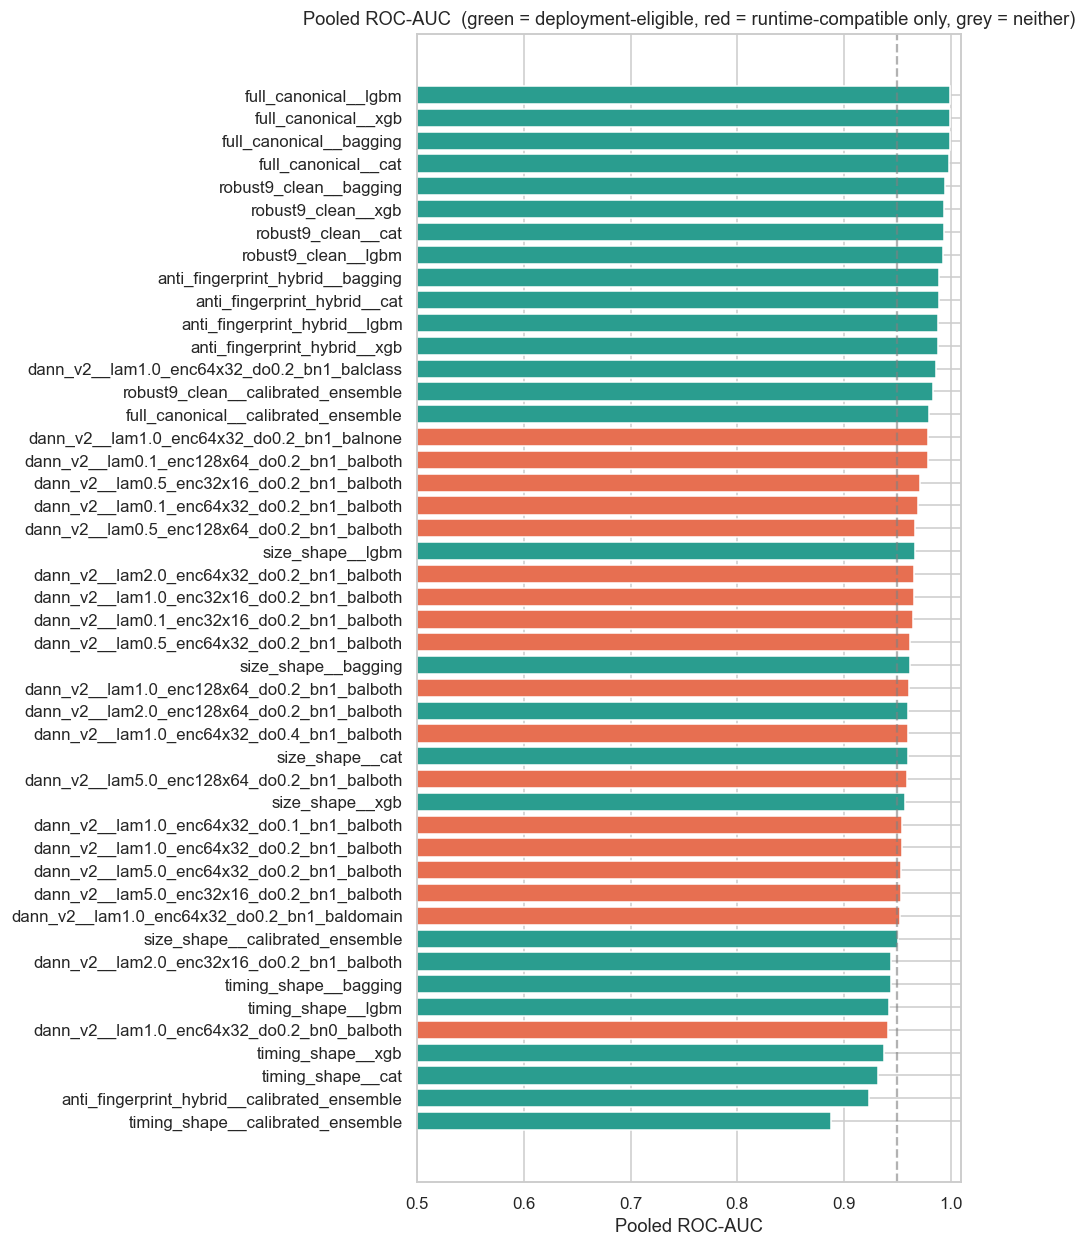

In [5]:
d = comp.sort_values('pooled_auc', ascending=True).copy()
d['_elig'] = d['deployment_eligible'].fillna(False)
colors = ['#2a9d8f' if e else ('#e76f51' if rc else '#cccccc')
          for e, rc in zip(d['_elig'], d['runtime_compatible'])]
fig, ax = plt.subplots(figsize=(9, max(4, 0.25 * len(d))))
ax.barh(d['model_id'], d['pooled_auc'], color=colors)
ax.set_xlabel('Pooled ROC-AUC')
ax.set_xlim(0.5, 1.01)
ax.axvline(0.95, ls='--', color='grey', alpha=.6)
ax.set_title('Pooled ROC-AUC  '
             '(green = deployment-eligible, red = runtime-compatible only, grey = neither)')
plt.tight_layout(); plt.show()


## 6. LODO AUC heatmap (transfer-evaluated models)

LODO fold columns: ['lodo_iscx_auc', 'lodo_usbvpn_auc', 'lodo_vnat_auc']


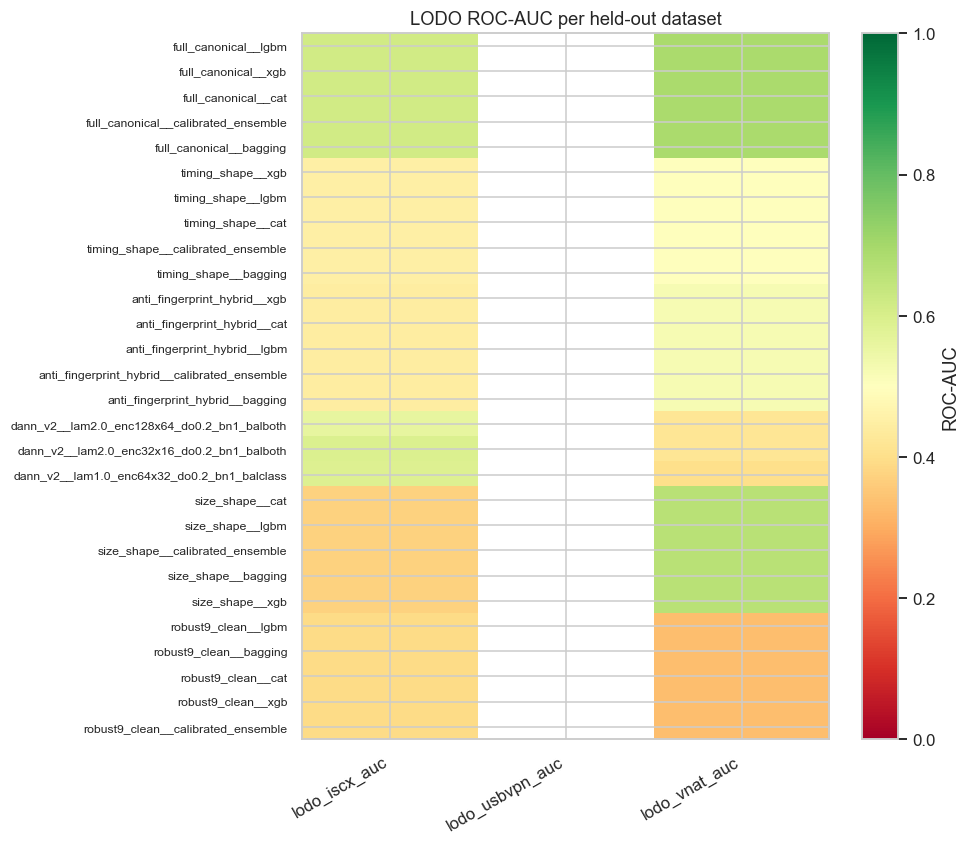

In [6]:
lodo_cols = [c for c in comp.columns if c.startswith('lodo_') and c.endswith('_auc')
              and c not in ('lodo_mean_auc', 'lodo_min_auc')]
print('LODO fold columns:', lodo_cols)

lodo_df = (transfer[['model_id'] + [c for c in lodo_cols if c in transfer.columns]]
           .set_index('model_id'))
if not lodo_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(lodo_df))))
    im = ax.imshow(lodo_df.values.astype(float), aspect='auto',
                   cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_yticks(range(len(lodo_df)))
    ax.set_yticklabels(lodo_df.index, fontsize=8)
    ax.set_xticks(range(len(lodo_df.columns)))
    ax.set_xticklabels(lodo_df.columns, rotation=30, ha='right')
    ax.set_title('LODO ROC-AUC per held-out dataset')
    plt.colorbar(im, ax=ax, label='ROC-AUC')
    plt.tight_layout(); plt.show()


## 7. LODO minimum AUC ranking (transfer hardness floor)

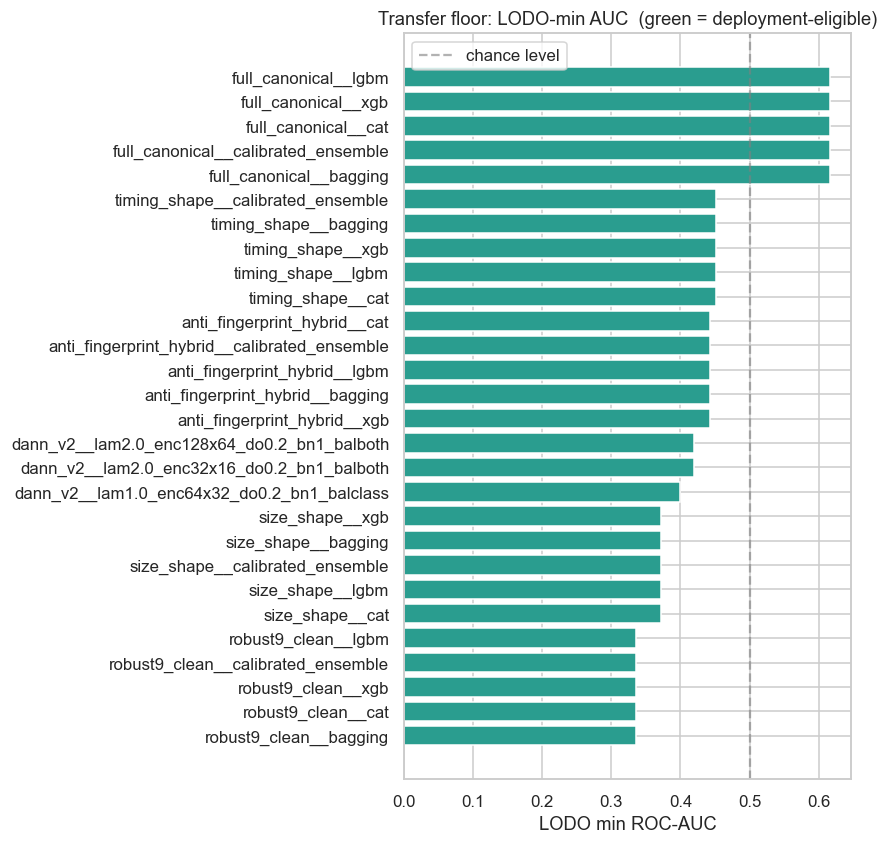

In [7]:
d = transfer.sort_values('lodo_min_auc', ascending=True).copy()
d['_elig'] = d['deployment_eligible'].fillna(False)
colors = ['#2a9d8f' if e else '#e76f51' for e in d['_elig']]
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
ax.barh(d['model_id'], d['lodo_min_auc'], color=colors)
ax.axvline(0.5, color='grey', ls='--', alpha=.6, label='chance level')
ax.set_xlabel('LODO min ROC-AUC')
ax.set_title('Transfer floor: LODO-min AUC  (green = deployment-eligible)')
ax.legend(); plt.tight_layout(); plt.show()


## 8. Domain (fingerprint) AUC — lower is better

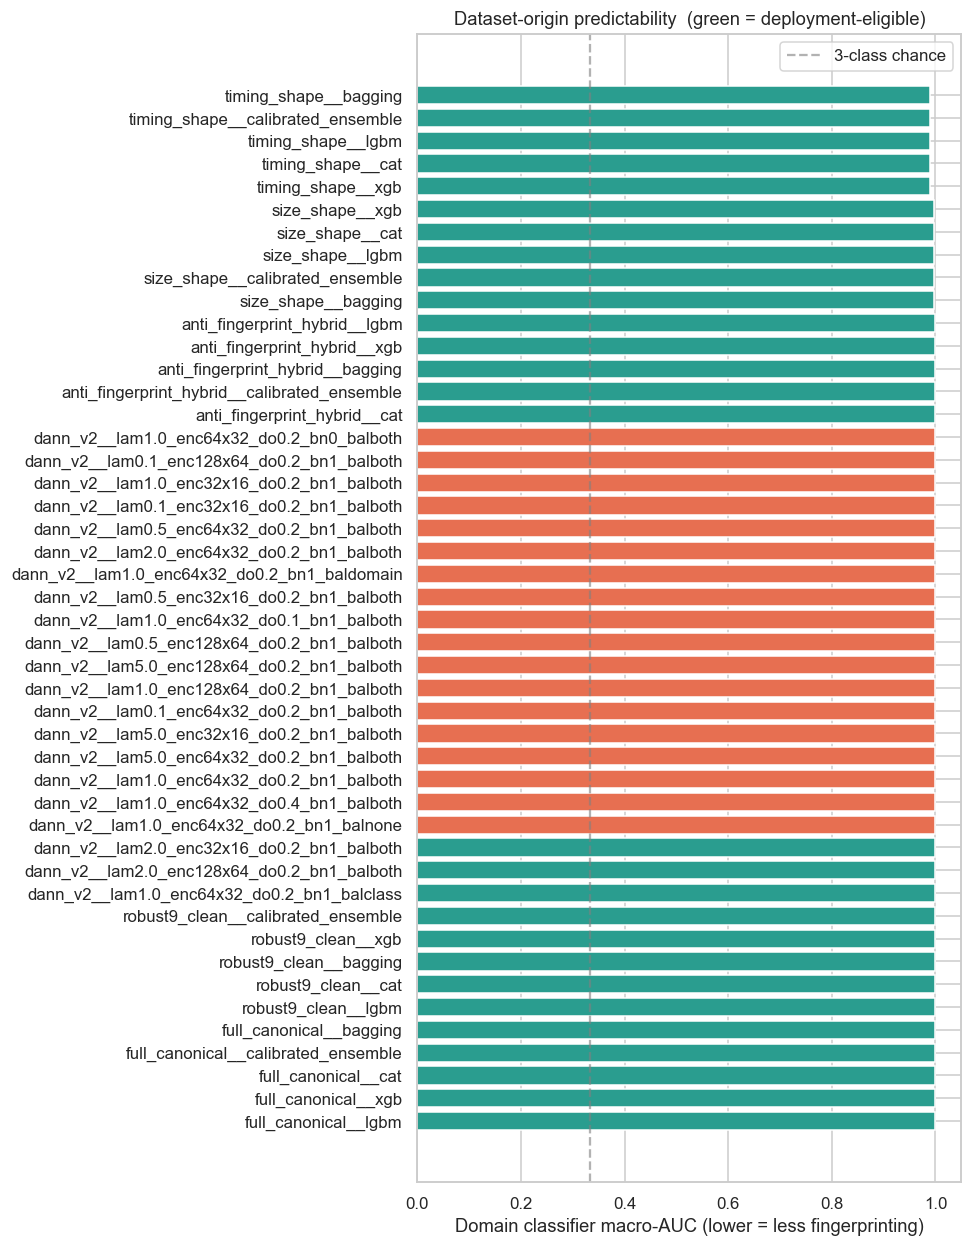

In [8]:
d = comp.dropna(subset=['domain_auc']).sort_values('domain_auc', ascending=False)
fig, ax = plt.subplots(figsize=(9, max(4, 0.25 * len(d))))
d['_elig'] = d['deployment_eligible'].fillna(False)
colors = ['#2a9d8f' if e else '#e76f51' for e in d['_elig']]
ax.barh(d['model_id'], d['domain_auc'], color=colors)
ax.axvline(1/3, color='grey', ls='--', alpha=.6, label='3-class chance')
ax.set_xlabel('Domain classifier macro-AUC (lower = less fingerprinting)')
ax.set_title('Dataset-origin predictability  (green = deployment-eligible)')
ax.legend(); plt.tight_layout(); plt.show()


## 9. VPN AUC vs Domain AUC scatter

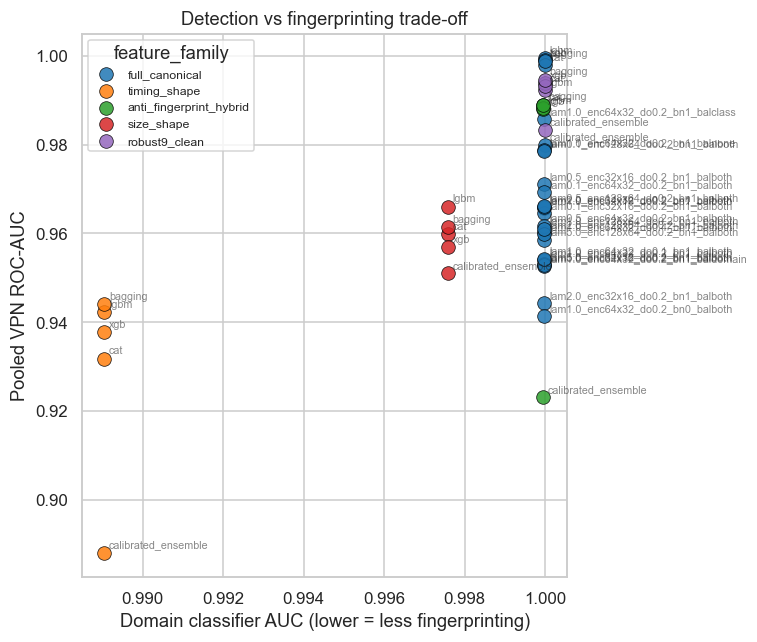

In [9]:
d = comp.dropna(subset=['pooled_auc', 'domain_auc']).copy()
fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.cm.tab10
for i, ff in enumerate(d['feature_family'].unique()):
    sub = d[d['feature_family'] == ff]
    ax.scatter(sub['domain_auc'], sub['pooled_auc'],
               s=80, alpha=.85, label=ff, color=cmap(i % 10),
               edgecolor='black', linewidth=.5)
for _, r in d.iterrows():
    ax.annotate(r['model_id'].split('__')[-1],
                (r['domain_auc'], r['pooled_auc']),
                fontsize=7, alpha=.55, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Domain classifier AUC (lower = less fingerprinting)')
ax.set_ylabel('Pooled VPN ROC-AUC')
ax.set_title('Detection vs fingerprinting trade-off')
ax.legend(fontsize=8, title='feature_family')
plt.tight_layout(); plt.show()


## 10. Calibration curves
Probability column priority: `prob_iso > prob_cal > prob > prob_raw > score > y_prob > p`


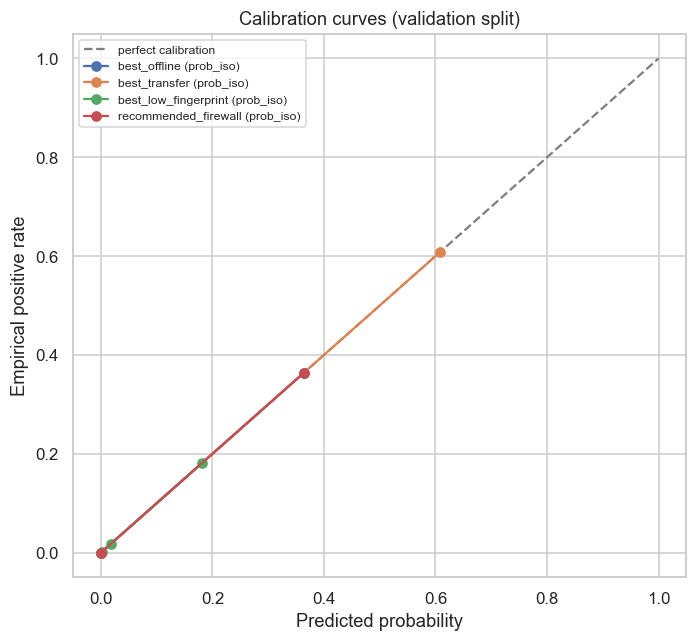

In [10]:
_PROB_COLS  = ('prob_iso', 'prob_cal', 'prob', 'prob_raw', 'score', 'y_prob', 'p')
_LABEL_COLS = ('y_true', 'label', 'y')

slots = ['best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall']
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect calibration')

for slot in slots:
    pf = REC / slot / 'val_predictions.csv'
    if not pf.exists():
        print(f'skip {slot}: no val_predictions'); continue
    dfp = pd.read_csv(pf)
    prob_col  = next((c for c in _PROB_COLS  if c in dfp.columns), None)
    y_col     = next((c for c in _LABEL_COLS if c in dfp.columns), None)
    if prob_col is None or y_col is None:
        print(f'skip {slot}: cols={list(dfp.columns)}'); continue
    frac, mean = calibration_curve(dfp[y_col], dfp[prob_col], n_bins=10, strategy='quantile')
    ax.plot(mean, frac, marker='o', label=f'{slot} ({prob_col})')

ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical positive rate')
ax.set_title('Calibration curves (validation split)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 11. Confusion-matrix grid (recommended slots)
Prob column priority: `prob_iso > prob_cal > prob > prob_raw`


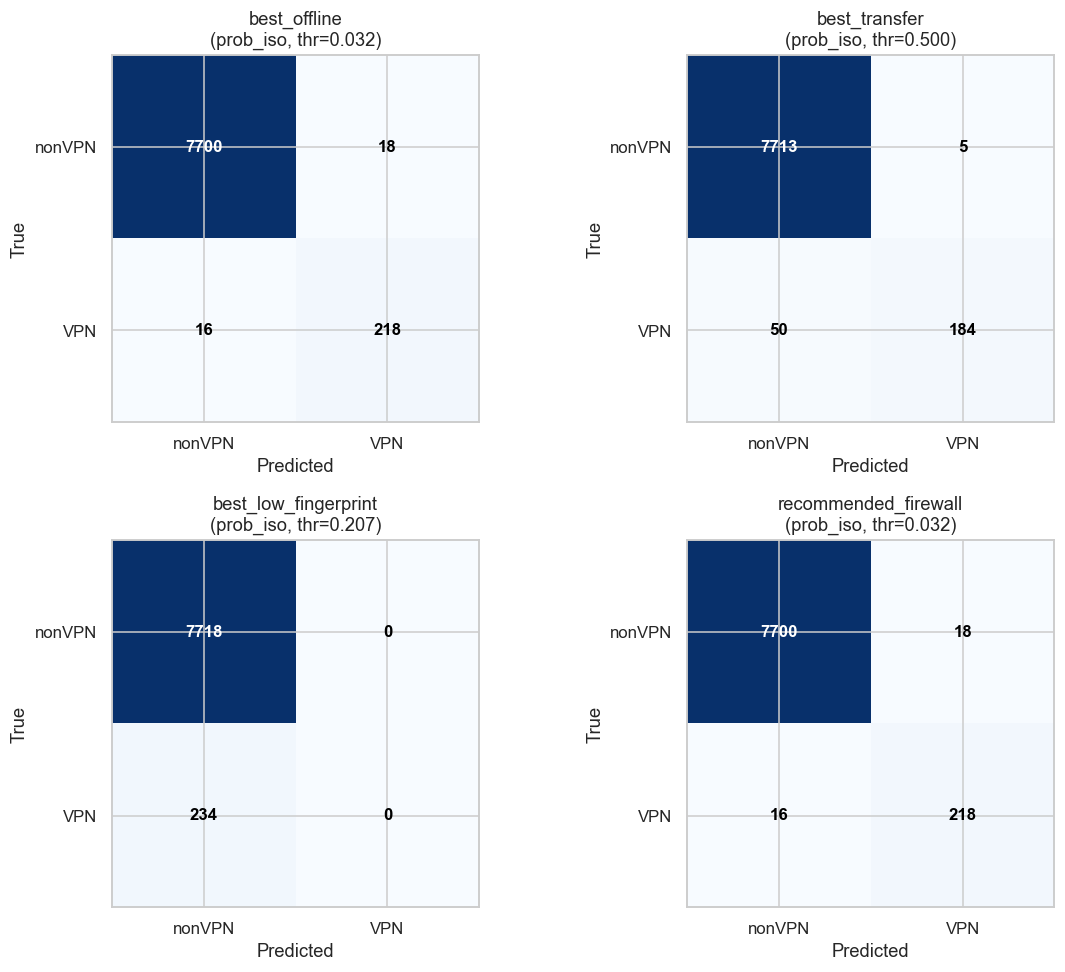

In [11]:
_PROB_COLS  = ('prob_iso', 'prob_cal', 'prob', 'prob_raw', 'score', 'y_prob', 'p')
_LABEL_COLS = ('y_true', 'label', 'y')

slot_dirs = [(s, REC / s) for s in
             ('best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall')
             if (REC / s).exists()]

n = len(slot_dirs)
if n == 0:
    print('No recommended slots found.')
else:
    cols2 = min(n, 2); rows2 = int(np.ceil(n / cols2))
    fig, axes = plt.subplots(rows2, cols2, figsize=(5.5 * cols2, 4.5 * rows2), squeeze=False)
    for ax, (slot, sd) in zip(axes.flatten(), slot_dirs):
        pf = sd / 'test_predictions.csv'
        tf = sd / 'thresholds.json'
        if not pf.exists():
            ax.set_visible(False); continue
        dfp = pd.read_csv(pf)
        prob_col = next((c for c in _PROB_COLS  if c in dfp.columns), None)
        y_col    = next((c for c in _LABEL_COLS if c in dfp.columns), None)
        if prob_col is None or y_col is None:
            ax.set_visible(False); continue
        thr = 0.5
        if tf.exists():
            try:
                tj = json.loads(tf.read_text(encoding='utf-8'))
                thr = float(tj.get('flow_threshold', tj.get('block_threshold', 0.5)))
            except Exception:
                pass
        pred = (dfp[prob_col] >= thr).astype(int)
        cm = confusion_matrix(dfp[y_col], pred, labels=[0, 1])
        ax.imshow(cm, cmap='Blues')
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, str(v), ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if v > cm.max() * 0.6 else 'black')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['nonVPN', 'VPN']); ax.set_yticklabels(['nonVPN', 'VPN'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{slot}\n({prob_col}, thr={thr:.3f})')
    for ax in axes.flatten()[len(slot_dirs):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()


## 12. Threshold stability across seeds

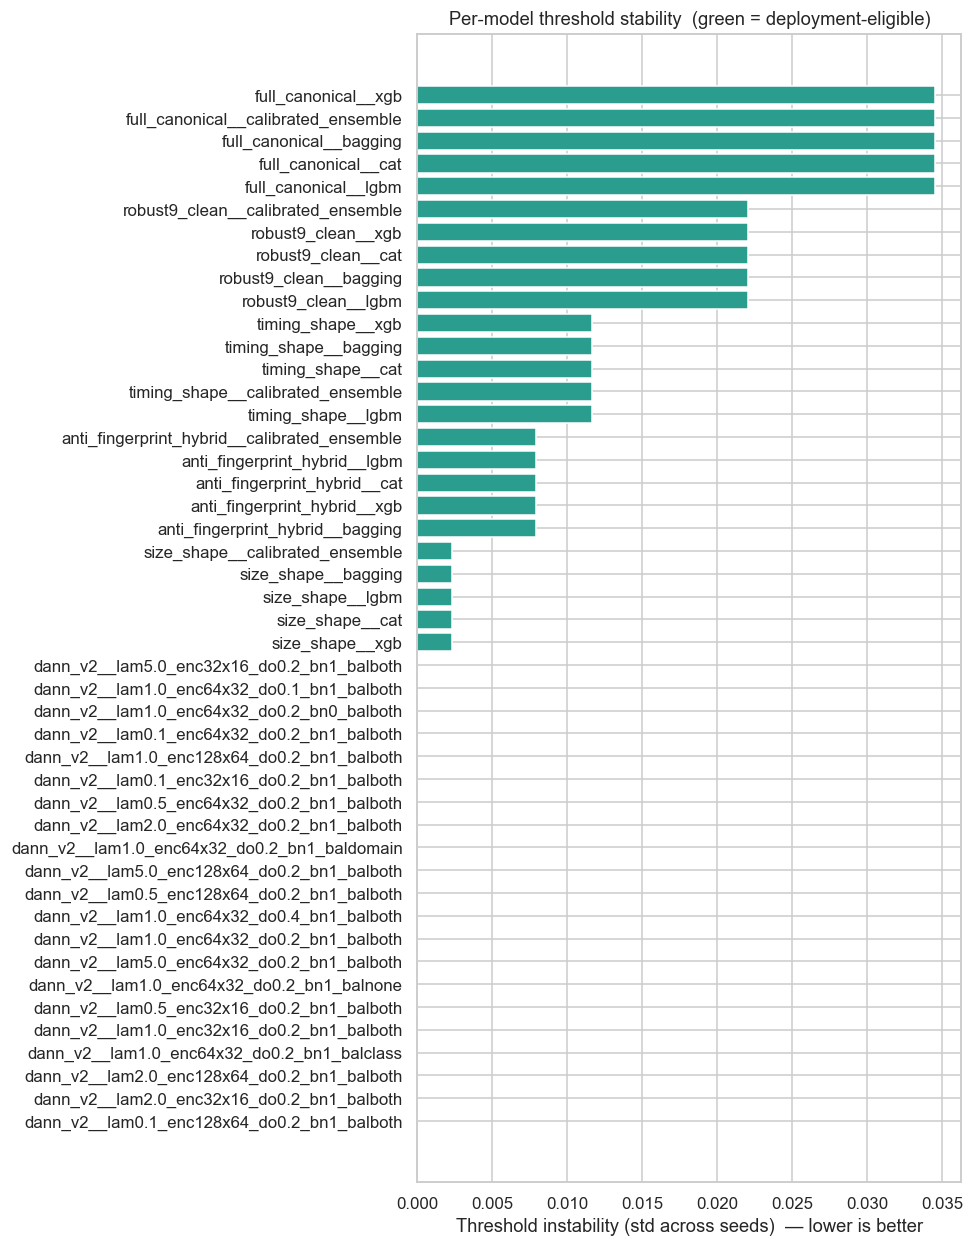

In [12]:
if 'threshold_instability' in comp.columns:
    d = comp.dropna(subset=['threshold_instability']).sort_values(
        'threshold_instability', ascending=True)
    d['_elig'] = d['deployment_eligible'].fillna(False)
    colors = ['#2a9d8f' if e else '#e76f51' for e in d['_elig']]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.25 * len(d))))
    ax.barh(d['model_id'], d['threshold_instability'], color=colors)
    ax.set_xlabel('Threshold instability (std across seeds)  — lower is better')
    ax.set_title('Per-model threshold stability  (green = deployment-eligible)')
    plt.tight_layout(); plt.show()


## 13. Anti-fingerprint feature importance

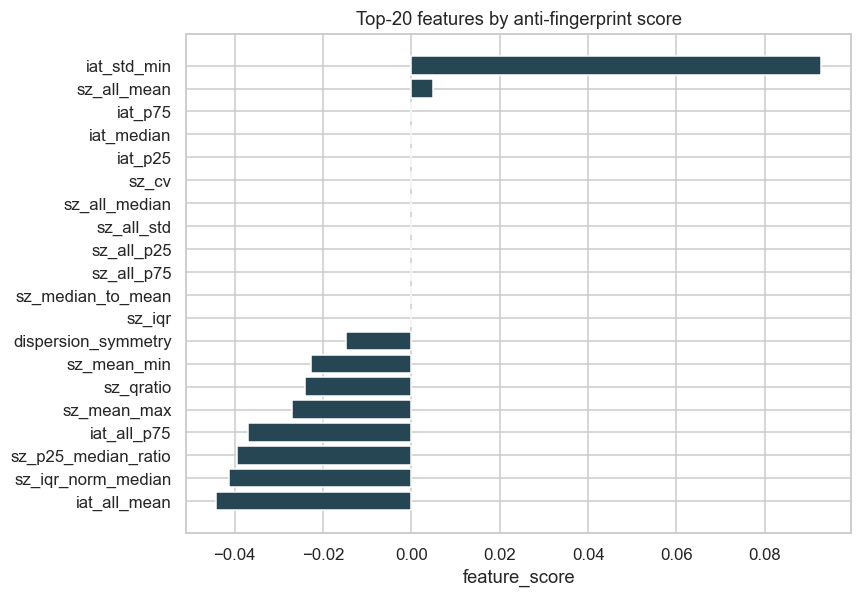

            feature  vpn_importance  domain_importance  instability_penalty  construction_penalty  feature_score
        iat_std_min          0.1118             0.0000               0.0636                   0.0         0.0928
        sz_all_mean          0.0050             0.0000               0.0000                   0.0         0.0050
            iat_p75          0.0000             0.0000               0.0000                   0.0         0.0000
         iat_median          0.0000             0.0000               0.0000                   0.0         0.0000
            iat_p25          0.0000             0.0000               0.0000                   0.0         0.0000
              sz_cv          0.0000             0.0000               0.0000                   0.0         0.0000
      sz_all_median          0.0000             0.0000               0.0000                   0.0         0.0000
         sz_all_std          0.0000             0.0000               0.0000                   0.

In [13]:
afp_path = ART / 'anti_fingerprint_scores.csv'
if not afp_path.exists():
    print('anti_fingerprint_scores.csv missing')
else:
    afp = pd.read_csv(afp_path)
    score_col = next((c for c in ('feature_score', 'score', 'final_score') if c in afp.columns), None)
    if score_col:
        afp = afp.sort_values(score_col, ascending=False).reset_index(drop=True)
        topk = afp.head(20)
        fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(topk))))
        ax.barh(topk['feature'][::-1], topk[score_col][::-1], color='#264653')
        ax.set_xlabel(score_col)
        ax.set_title('Top-20 features by anti-fingerprint score')
        plt.tight_layout(); plt.show()
        print(afp.head(20).round(4).to_string(index=False))


## 14. Final recommendation summary

In [14]:
rec_path = ART / 'recommended_models.json'
if not rec_path.exists():
    print('recommended_models.json missing')
else:
    rec = json.loads(rec_path.read_text(encoding='utf-8'))
    rows_r = []
    for slot, info in rec.items():
        d = dict(info); d.pop('metrics', None); d['slot'] = slot
        rows_r.append(d)
    summary = pd.DataFrame(rows_r)
    keep = [c for c in [
        'slot', 'model_id', 'feature_family', 'family', 'n_features',
        'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
        'domain_auc', 'fpr', 'ece', 'threshold_instability',
        'runtime_compatible', 'deployment_final_score', 'final_score',
    ] if c in summary.columns]
    print('=== Recommended models ===')
    print(summary[keep].set_index('slot').round(4).to_string())
    fw = rec.get('recommended_firewall', {})
    dfs = fw.get('deployment_final_score', fw.get('final_score', 'n/a'))
    print(f'''
>>> FIREWALL PROTOTYPE RECOMMENDATION <<<
  model_id                 : {fw.get("model_id")}
  feature_family           : {fw.get("feature_family")}
  n_features               : {fw.get("n_features")}
  pooled_auc               : {fw.get("pooled_auc")}
  lodo_min_auc             : {fw.get("lodo_min_auc")}
  domain_auc               : {fw.get("domain_auc")}
  runtime_compatible       : {fw.get("runtime_compatible")}
  deployment_final_score   : {dfs}
  selection_criterion      : deployment_eligible == True, highest deployment_final_score
''')


=== Recommended models ===
                                  model_id  feature_family family  n_features  pooled_auc  lodo_min_auc  lodo_mean_auc  domain_auc     fpr     ece  threshold_instability  runtime_compatible  deployment_final_score  final_score
slot                                                                                                                                                                                                                              
best_offline          full_canonical__lgbm  full_canonical   lgbm          34      0.9994        0.6164         0.6531      1.0000  0.0025  0.0026                 0.0346                True                  0.6836       0.4336
best_transfer         full_canonical__lgbm  full_canonical   lgbm          34      0.9994        0.6164         0.6531      1.0000  0.0025  0.0026                 0.0346                True                  0.6836       0.4336
best_low_fingerprint    timing_shape__lgbm    timing_shape   lgbm

## 15. DANN v2 — Architecture Verification & Domain Reduction

> **Warning:** DANN v2 models are **not** selected as firewall candidates
> unless their LODO metrics are available and competitive.  Only 3 out of
> 21 DANN v2 configs have LODO numbers; none achieves `embedding_domain_auc`
> below 0.999 — well above the 3-class chance level of 0.333.

Reads `artifacts/final_transfer/dann_v2/dann_v2_results.csv`.


In [15]:
dann_v2_path = ART / 'dann_v2' / 'dann_v2_results.csv'
if not dann_v2_path.exists():
    print('dann_v2_results.csv not found — run scripts/dann_improved.py first.')
    dann_v2 = pd.DataFrame()
else:
    dann_v2 = pd.read_csv(dann_v2_path)
    print(f'{len(dann_v2)} DANN v2 rows loaded.')
    # merge dann_research_score / deployment_eligible from main comparison if absent
    for extra_col in ('dann_research_score', 'deployment_eligible', 'deployment_final_score'):
        if extra_col not in dann_v2.columns and extra_col in comp.columns:
            dann_v2 = dann_v2.merge(
                comp[['model_id', extra_col]], on='model_id', how='left')
    show_cols = [c for c in [
        'model_id', 'dann_lambda', 'enc_hidden', 'dropout', 'balanced',
        'pooled_auc', 'input_domain_auc', 'embedding_domain_auc',
        'domain_reduction', 'lodo_min_auc', 'ece', 'dann_research_score',
        'deployment_eligible',
    ] if c in dann_v2.columns]
    sort_col = next((c for c in ('dann_research_score', 'pooled_auc') if c in dann_v2.columns), None)
    dann_v2[show_cols].sort_values(sort_col, ascending=False).head(20).round(4)


21 DANN v2 rows loaded.


### 15a. Lambda sweep — VPN AUC vs Embedding Domain AUC

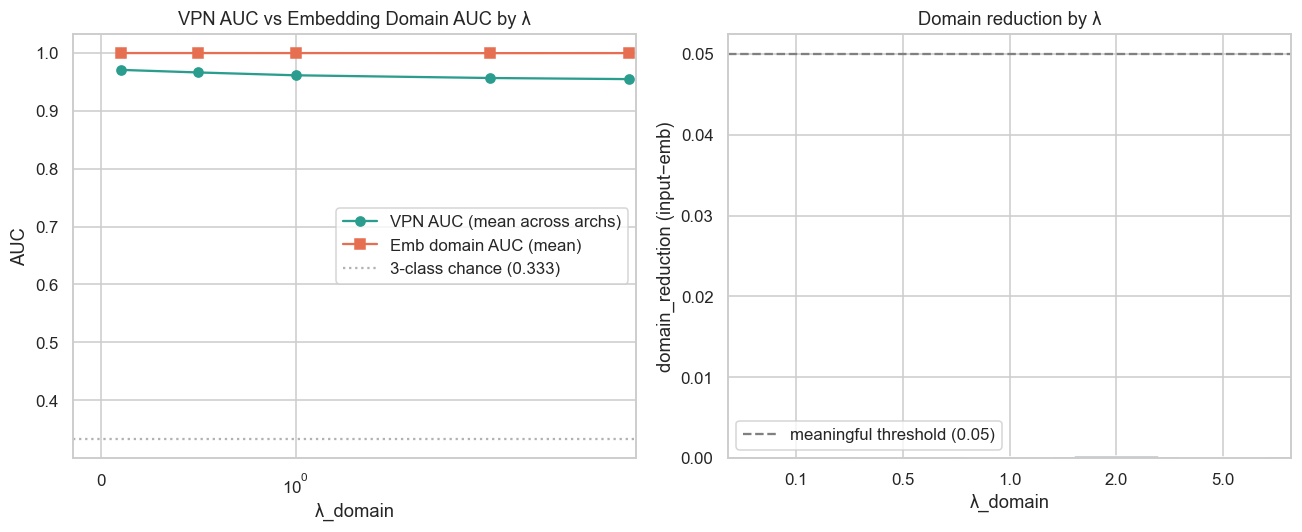

In [16]:
if not dann_v2.empty and 'dann_lambda' in dann_v2.columns:
    d = dann_v2.dropna(subset=['dann_lambda','pooled_auc','embedding_domain_auc'])
    by_lam = (d.sort_values('dann_lambda')
              .groupby('dann_lambda')[['pooled_auc','embedding_domain_auc','domain_reduction']]
              .mean().reset_index())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(by_lam['dann_lambda'], by_lam['pooled_auc'],
                 marker='o', color='#2a9d8f', label='VPN AUC (mean across archs)')
    axes[0].plot(by_lam['dann_lambda'], by_lam['embedding_domain_auc'],
                 marker='s', color='#e76f51', label='Emb domain AUC (mean)')
    axes[0].axhline(1/3, color='grey', ls=':', alpha=.6, label='3-class chance (0.333)')
    axes[0].set_xlabel('λ_domain'); axes[0].set_ylabel('AUC')
    axes[0].set_title('VPN AUC vs Embedding Domain AUC by λ'); axes[0].legend()
    axes[0].set_xscale('symlog')
    axes[1].bar(by_lam['dann_lambda'].astype(str), by_lam['domain_reduction'], color='#264653')
    axes[1].axhline(0.05, ls='--', color='grey', label='meaningful threshold (0.05)')
    axes[1].set_xlabel('λ_domain'); axes[1].set_ylabel('domain_reduction (input−emb)')
    axes[1].set_title('Domain reduction by λ')
    axes[1].legend(); plt.tight_layout(); plt.show()


### 15b. Input vs Embedding domain AUC scatter (all configs)

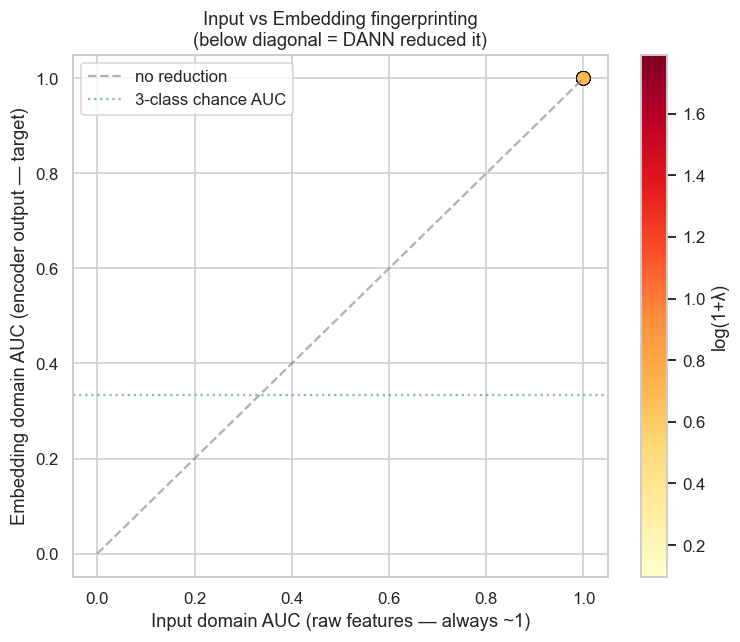

In [17]:
if not dann_v2.empty and 'embedding_domain_auc' in dann_v2.columns:
    d = dann_v2.dropna(subset=['input_domain_auc','embedding_domain_auc'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(d['input_domain_auc'], d['embedding_domain_auc'],
                    c=np.log1p(d['dann_lambda']), cmap='YlOrRd',
                    s=80, edgecolor='black', linewidth=0.5)
    ax.plot([0, 1], [0, 1], '--', color='grey', alpha=0.6, label='no reduction')
    ax.axhline(1/3, color='steelblue', ls=':', alpha=0.6, label='3-class chance AUC')
    ax.set_xlabel('Input domain AUC (raw features — always ~1)')
    ax.set_ylabel('Embedding domain AUC (encoder output — target)')
    ax.set_title('Input vs Embedding fingerprinting\n(below diagonal = DANN reduced it)')
    plt.colorbar(sc, ax=ax, label='log(1+λ)')
    ax.legend(); plt.tight_layout(); plt.show()


### 15c. Training curves (first complete config)

Configs in training_curves.json: 21


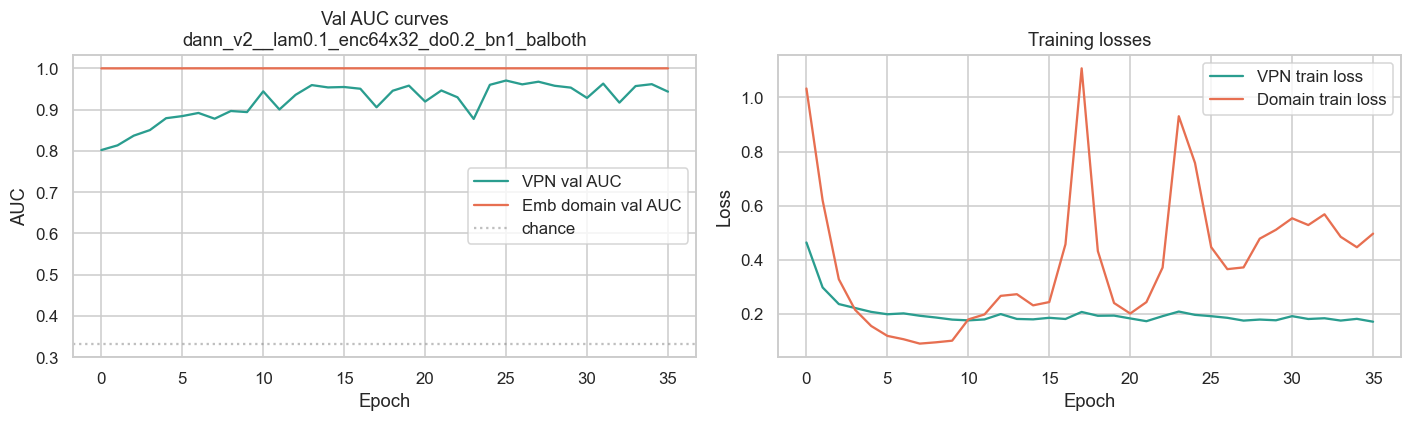

Config shown: dann_v2__lam0.1_enc64x32_do0.2_bn1_balboth


In [18]:
curves_path = ART / 'dann_v2' / 'dann_v2_training_curves.json'
if not curves_path.exists():
    print('Training curves not found.')
else:
    curves = json.loads(curves_path.read_text(encoding='utf-8'))
    print(f'Configs in training_curves.json: {len(curves)}')
    for cid, hist in curves.items():
        if all(k in hist for k in ('vpn_val_auc','emb_domain_val_auc',
                                    'vpn_train_loss','dom_train_loss')):
            ep = range(len(hist['vpn_val_auc']))
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))
            axes[0].plot(ep, hist['vpn_val_auc'], color='#2a9d8f', label='VPN val AUC')
            axes[0].plot(ep, hist['emb_domain_val_auc'], color='#e76f51',
                         label='Emb domain val AUC')
            axes[0].axhline(1/3, color='grey', ls=':', alpha=.5, label='chance')
            axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
            axes[0].set_title(f'Val AUC curves\n{cid[:55]}'); axes[0].legend()
            axes[1].plot(ep, hist['vpn_train_loss'], color='#2a9d8f', label='VPN train loss')
            axes[1].plot(ep, hist['dom_train_loss'], color='#e76f51', label='Domain train loss')
            axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
            axes[1].set_title('Training losses'); axes[1].legend()
            plt.tight_layout(); plt.show()
            print(f'Config shown: {cid}'); break


### 15d. Multi-objective score trajectories

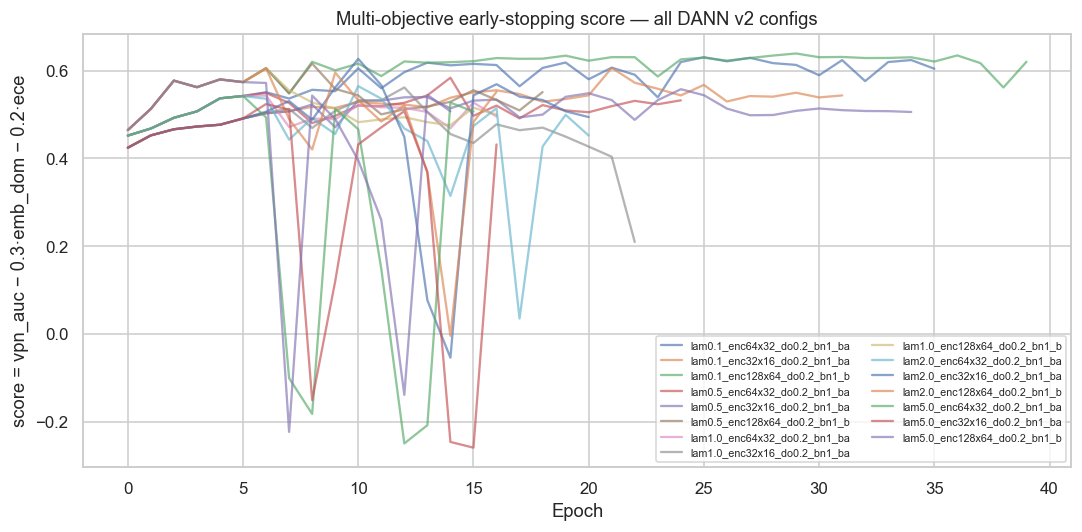

In [19]:
if 'curves_path' in dir() and curves_path.exists() and curves:
    fig, ax = plt.subplots(figsize=(10, 5))
    for cid, hist in list(curves.items())[:15]:
        if 'multi_obj_score' in hist:
            lbl = cid.split('__')[1][:28] if '__' in cid else cid[:28]
            ax.plot(hist['multi_obj_score'], alpha=0.65, label=lbl)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('score = vpn_auc − 0.3·emb_dom − 0.2·ece')
    ax.set_title('Multi-objective early-stopping score — all DANN v2 configs')
    ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()


### 15e. DANN v2 verdict

In [20]:
if not dann_v2.empty:
    best_red = dann_v2['domain_reduction'].max() if 'domain_reduction' in dann_v2.columns else 0
    # best by dann_research_score when available
    sc = 'dann_research_score' if 'dann_research_score' in dann_v2.columns else 'pooled_auc'
    best_d = dann_v2.dropna(subset=[sc]).sort_values(sc, ascending=False).iloc[0]
    print('=== DANN v2 Verdict ===')
    print(f'  Configs tested           : {len(dann_v2)}')
    print(f'  Lambda sweep             : {sorted(dann_v2["dann_lambda"].dropna().unique().tolist())}')
    print(f'  Best domain_reduction    : {best_red:.5f}')
    print(f'  ==  Best config (by {sc})  ==')
    print(f'     model_id              : {best_d["model_id"]}')
    print(f'     dann_lambda           : {best_d.get("dann_lambda")}')
    print(f'     pooled_auc            : {best_d["pooled_auc"]:.4f}')
    if 'embedding_domain_auc' in best_d.index:
        print(f'     input_domain_auc      : {best_d["input_domain_auc"]:.4f}')
        print(f'     embedding_domain_auc  : {best_d["embedding_domain_auc"]:.4f}')
    if 'lodo_min_auc' in best_d.index and pd.notna(best_d.get('lodo_min_auc')):
        print(f'     lodo_min_auc          : {best_d["lodo_min_auc"]:.4f}')
    print(f'     dann_research_score   : {best_d.get(sc, "n/a")}')
    elig = dann_v2['deployment_eligible'].sum() if 'deployment_eligible' in dann_v2.columns else 0
    print(f'  deployment_eligible      : {elig}/{len(dann_v2)} configs')
    if best_red > 0.05:
        verdict = 'SUCCESS — DANN v2 reduced embedding fingerprinting (>0.05)'
    elif best_red > 0.01:
        verdict = 'MARGINAL — small domain reduction, insufficient for deployment advantage'
    else:
        verdict = ('NO MEANINGFUL REDUCTION  — domain shift is structural.\n'
                   '  The GRL did not push embedding_domain_auc below 0.999 regardless\n'
                   '  of λ (0.1–5.0), architecture, dropout, BN, or balancing strategy.\n'
                   '  Consistent with NB51/52 findings.')
    print(f'\n  VERDICT: {verdict}')
    print('\n  NOTE: recommended_firewall remains full_canonical__lgbm (deployment_eligible,')
    print('        highest deployment_final_score among LODO-evaluated models).')


=== DANN v2 Verdict ===
  Configs tested           : 21
  Lambda sweep             : [0.1, 0.5, 1.0, 2.0, 5.0]
  Best domain_reduction    : 0.00033
  ==  Best config (by dann_research_score)  ==
     model_id              : dann_v2__lam1.0_enc64x32_do0.2_bn1_balnone
     dann_lambda           : 1.0
     pooled_auc            : 0.9787
     input_domain_auc      : 1.0000
     embedding_domain_auc  : 0.9999
     dann_research_score   : 0.6726652315809464
  deployment_eligible      : 3/21 configs

  VERDICT: NO MEANINGFUL REDUCTION  — domain shift is structural.
  The GRL did not push embedding_domain_auc below 0.999 regardless
  of λ (0.1–5.0), architecture, dropout, BN, or balancing strategy.
  Consistent with NB51/52 findings.

  NOTE: recommended_firewall remains full_canonical__lgbm (deployment_eligible,
        highest deployment_final_score among LODO-evaluated models).
